# Моделирование системы обслуживания с использованием SimPy

Данный IPython ноутбук представляет собой симуляцию системы обслуживания (например, кассового узла в магазине) с использованием библиотеки SimPy. Целью является анализ влияния различных параметров, таких как количество обслуживающих касс и терпение клиентов, на ключевые метрики системы: длину очереди, время ожиданий и количество обслуженных/потерянных клиентов.

Мы рассмотрим две основные конфигурации симуляции:
1. **Базовая модель:** Клиенты ожидают обслуживания без ограничений по времени.
2. **Модель с терпением клиентов:** Клиенты могут уйти из очереди, если их время ожидания превышает определенный порог (терпение).

Для каждой конфигурации будут построены графики, иллюстрирующие динамику очереди и время пребывания клиентов в системе, а также проведено сравнение ключевых показателей.

## Настройка окружения и импорт библиотек

Перед началом симуляции необходимо установить необходимые библиотеки `simpy` для моделирования и `matplotlib` для визуализации данных. Затем импортируем их.

In [1]:
!pip install simpy matplotlib seaborn

In [2]:
import simpy
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import pandas as pd

## Определение параметров модели

Здесь задаются основные параметры, которые будут использоваться в симуляции:
- `MAX_SERVICE_DURATION`, `MODE_SERVICE_DURATION`, `MIN_SERVICE_DURATION`: определяют распределение времени обслуживания клиентов (треугольное распределение).
- `ARRIV_INTER`: максимальный интервал между прибытиями новых клиентов.
- `CONSUMER_TIME`: общая продолжительность симуляции в секундах.

In [3]:
# Параметры модели (в секундах)
MAX_SERVICE_DURATION = 20 * 60  # Максимальное время обслуживания (20 минут)
MODE_SERVICE_DURATION = 7 * 60   # Модальное время обслуживания (7 минут)
MIN_SERVICE_DURATION = 30       # Минимальное время обслуживания (30 секунд)
ARRIV_INTER = 3 * 60           # Максимальный интервал между прибытиями (3 минуты)
SIMULATION_TIME = 12 * 60 * 60 # Общая продолжительность симуляции (12 часов)

## Базовая симуляция системы обслуживания

Функция `run_simulation_base` реализует базовую модель без учета терпения клиентов. Клиенты прибывают, встают в очередь, ожидают свободную кассу, обслуживаются и покидают систему. Собираются данные о длине очереди и времени пребывания клиентов в системе.

In [4]:
def run_simulation_base(capacity):
    env = simpy.Environment()
    cashier = simpy.Resource(env, capacity=capacity)
    quelog = []  # Лог длины очереди: (время, длина_очереди)
    tservlog = [] # Лог времени пребывания в системе: (время_ухода, время_в_системе)
    
    class Client(object):
        def __init__(self, env, res, name='client'):
            self.name = name
            self.env = env
            self.res = res

        def run(self):
            nonlocal quelog, tservlog
            arrival_time = self.env.now
            
            with self.res.request() as req:
                yield req
                start_service_time = self.env.now
                # Записываем длину очереди в момент начала обслуживания
                quelog.append((start_service_time, len(self.res.queue)))
                
                serving_duration = int(random.triangular(
                    MIN_SERVICE_DURATION, 
                    MAX_SERVICE_DURATION, 
                    MODE_SERVICE_DURATION
                ))
                yield env.timeout(serving_duration)
                
                departure_time = self.env.now
                time_in_system = departure_time - arrival_time
                tservlog.append((departure_time, time_in_system))

    def source_men(env):
        ind = 0
        while env.now < (SIMULATION_TIME - ARRIV_INTER):
            ind += 1
            # Интервал между прибытиями случайный, от 0 до ARRIV_INTER
            yield env.timeout(random.randint(0, ARRIV_INTER))
            man = Client(env, cashier, name=f'клиент{ind}')
            env.process(man.run())

    random.seed(13971) # Для воспроизводимости результатов
    env.process(source_men(env))
    env.run(until=SIMULATION_TIME)
    
    return quelog, tservlog

## Запуск базовых симуляций

Здесь мы запускаем симуляции для различных конфигураций количества касс и сохраняем результаты.

In [5]:
configs_base = [6, 5, 4, 3] # Количество касс для симуляции
results_base = {}
for i, cap in enumerate(configs_base):
    results_base[f'config_{cap}_cashiers'] = run_simulation_base(cap)
    print(f"Базовая симуляция с {cap} кассами завершена.")

Базовая симуляция с 6 кассами завершена.
Базовая симуляция с 5 кассами завершена.
Базовая симуляция с 4 кассами завершена.
Базовая симуляция с 3 кассами завершена.


## Визуализация результатов базовой симуляции

Строим графики для анализа:
- **Длина очереди со временем**: показывает, как меняется количество клиентов в очереди.
- **Время пребывания в системе**: распределение времени, которое клиенты проводят от момента прибытия до завершения обслуживания.

Используем `seaborn` для улучшения эстетики графиков.

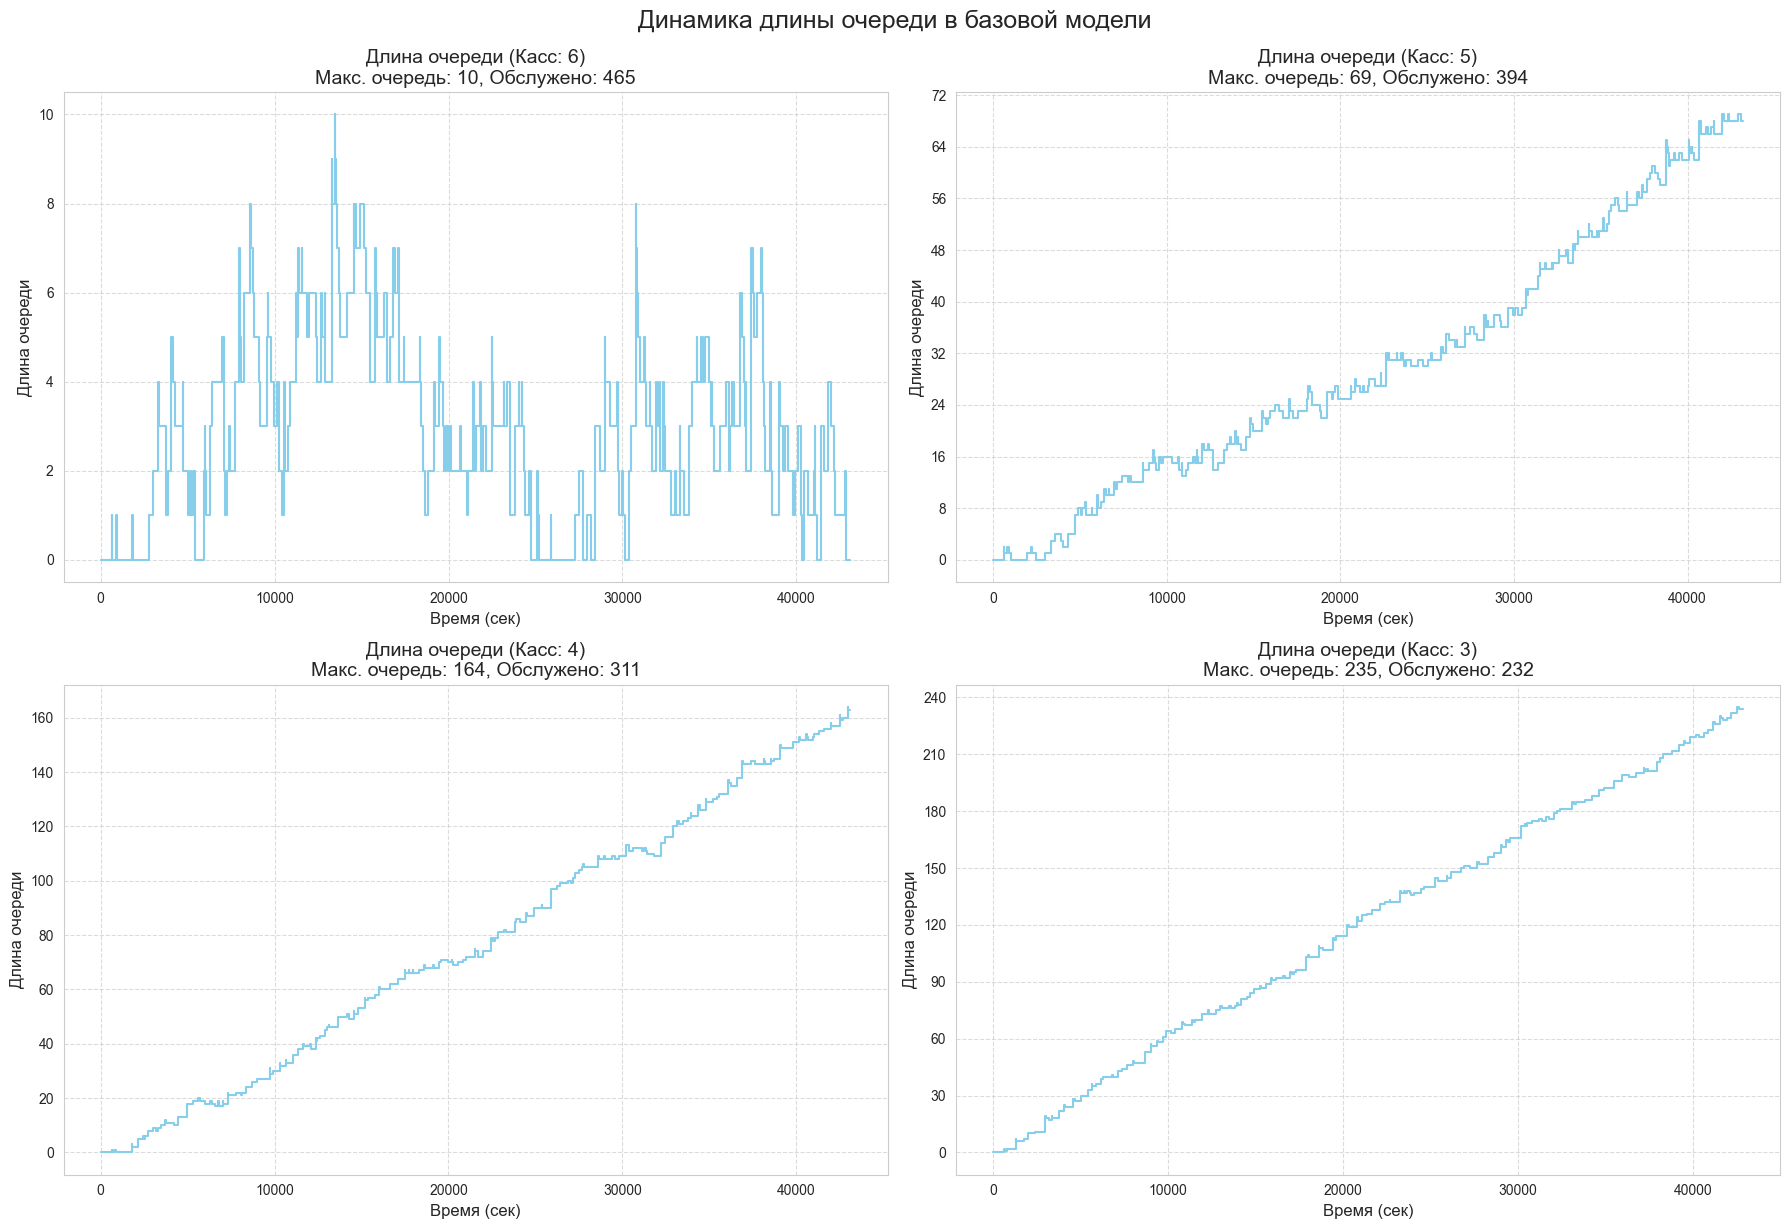

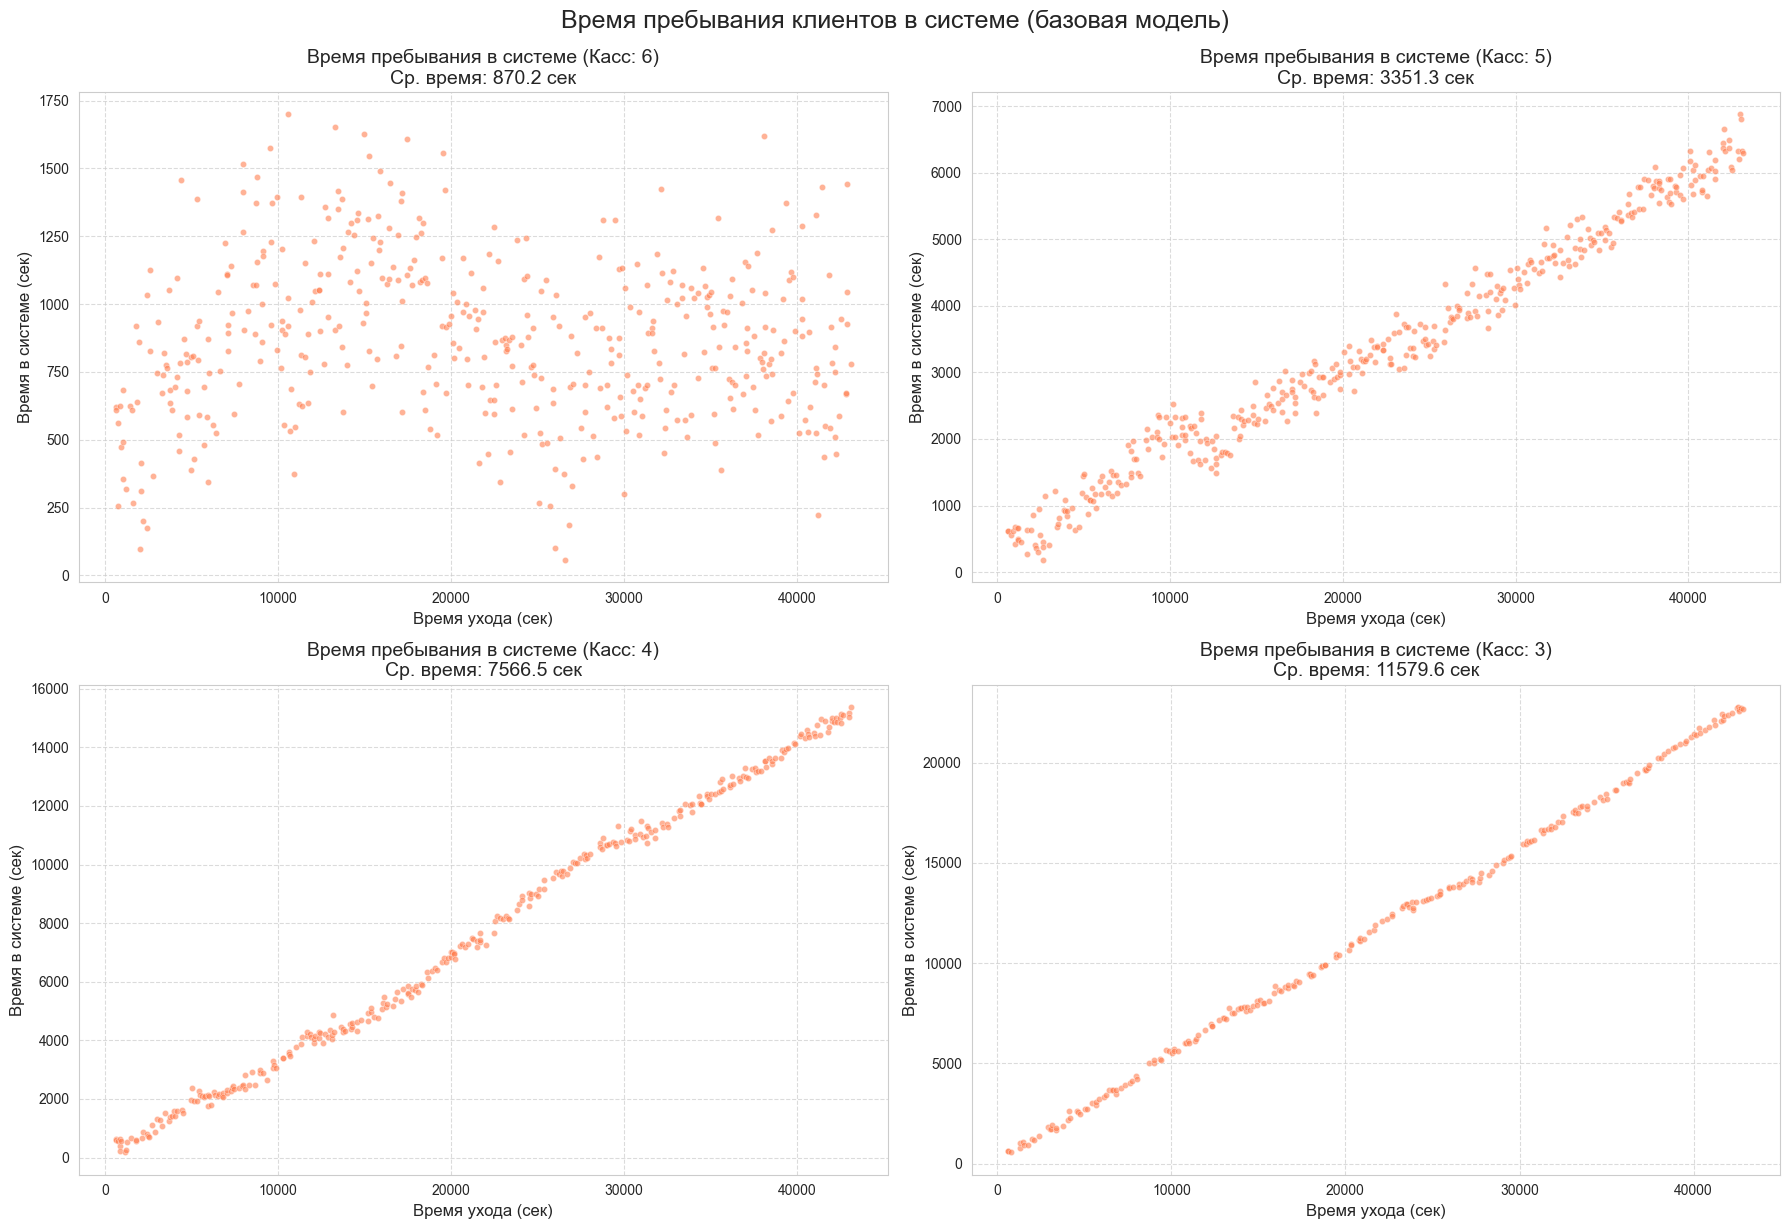

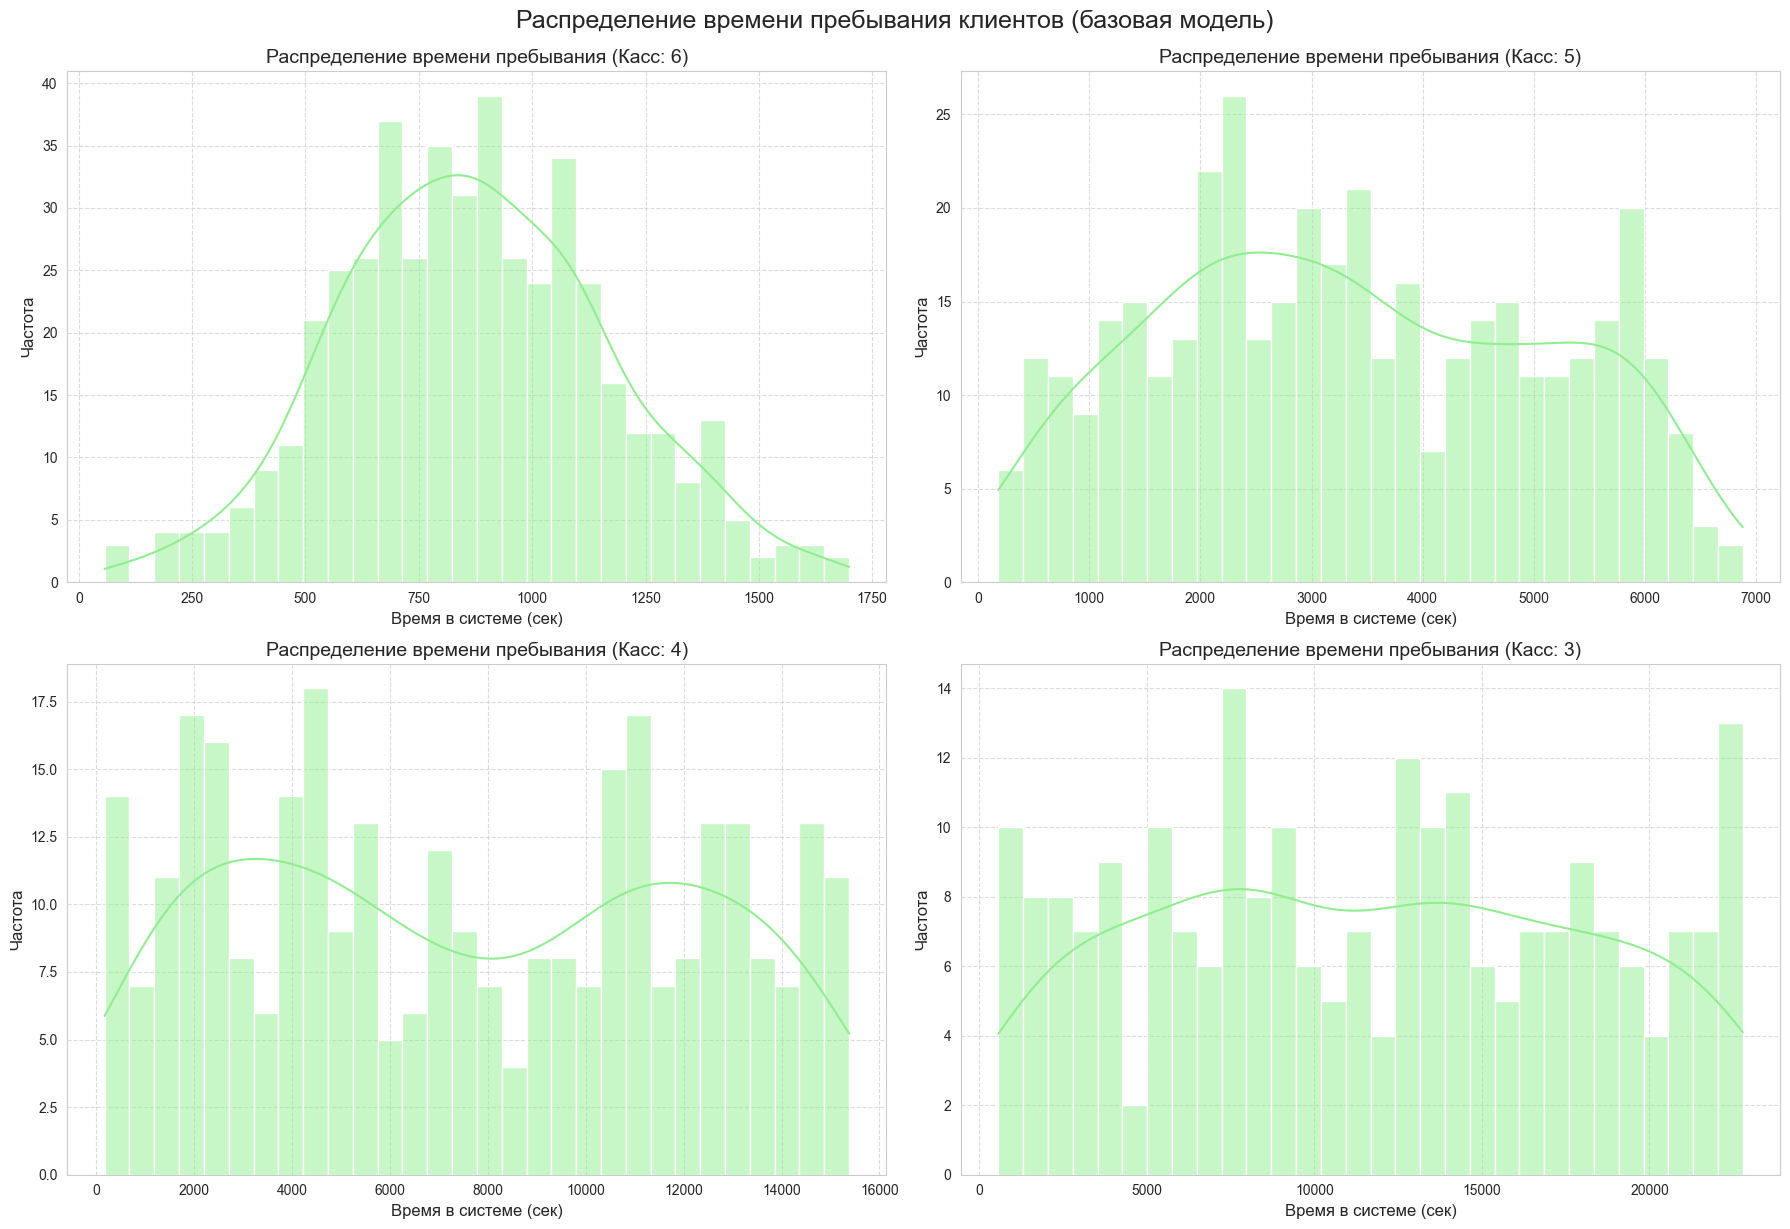

In [6]:
sns.set_style("whitegrid")

plt.figure(figsize=(18, 12))

for i, (config_name, (quelog, tservlog)) in enumerate(results_base.items(), 1):
    num_cashiers = int(config_name.split('_')[1])

    # График длины очереди
    plt.subplot(2, 2, i)
    if quelog:
        times, lengths = zip(*quelog)
        plt.step(times, lengths, where='post', color='skyblue')
        max_queue = max(lengths)
        total_clients = len(tservlog)
        plt.title(f'Длина очереди (Касс: {num_cashiers})\nМакс. очередь: {max_queue}, Обслужено: {total_clients}', fontsize=14)
        plt.xlabel('Время (сек)', fontsize=12)
        plt.ylabel('Длина очереди', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f'Длина очереди (Касс: {num_cashiers})\nОчереди не было', fontsize=14)
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.suptitle('Динамика длины очереди в базовой модели', y=1.02, fontsize=18)
plt.show()

plt.figure(figsize=(18, 12))
for i, (config_name, (quelog, tservlog)) in enumerate(results_base.items(), 1):
    num_cashiers = int(config_name.split('_')[1])

    # График времени пребывания
    plt.subplot(2, 2, i)
    if tservlog:
        times, durations = zip(*tservlog)
        sns.scatterplot(x=list(times), y=list(durations), s=20, alpha=0.6, color='coral')
        avg_time = sum(durations)/len(durations)
        plt.title(f'Время пребывания в системе (Касс: {num_cashiers})\nСр. время: {avg_time:.1f} сек', fontsize=14)
        plt.xlabel('Время ухода (сек)', fontsize=12)
        plt.ylabel('Время в системе (сек)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f'Время пребывания в системе (Касс: {num_cashiers})\nНет данных', fontsize=14)
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(5))

plt.tight_layout()
plt.suptitle('Время пребывания клиентов в системе (базовая модель)', y=1.02, fontsize=18)
plt.show()

# Дополнительные графики: гистограммы времени пребывания
plt.figure(figsize=(18, 12))
for i, (config_name, (quelog, tservlog)) in enumerate(results_base.items(), 1):
    num_cashiers = int(config_name.split('_')[1])

    plt.subplot(2, 2, i)
    if tservlog:
        durations = [d for _, d in tservlog]
        sns.histplot(durations, bins=30, kde=True, color='lightgreen')
        plt.title(f'Распределение времени пребывания (Касс: {num_cashiers})', fontsize=14)
        plt.xlabel('Время в системе (сек)', fontsize=12)
        plt.ylabel('Частота', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f'Распределение времени пребывания (Касс: {num_cashiers})\nНет данных', fontsize=14)

plt.tight_layout()
plt.suptitle('Распределение времени пребывания клиентов (базовая модель)', y=1.02, fontsize=18)
plt.show()

## Симуляция системы обслуживания с учетом терпения клиентов

Функция `run_simulation_patience` расширяет базовую модель, добавляя концепцию "терпения" клиентов. Каждый клиент имеет случайное время максимального ожидания. Если это время истекает до того, как клиент попадает на кассу, он уходит из очереди. Это позволяет оценить потери клиентов и влияние терпения на динамику системы.

In [7]:
def run_simulation_patience(capacity):
    env = simpy.Environment()
    cashier = simpy.Resource(env, capacity=capacity)
    quelog = []
    tservlog = []
    lost_clients = 0  # Счетчик клиентов, ушедших из очереди
    
    class Client(object):
        def __init__(self, env, res, name='client'):
            self.name = name
            self.env = env
            self.res = res

        def run(self):
            nonlocal quelog, tservlog, lost_clients
            arrival_time = self.env.now
            # Случайное время допустимого ожидания от 2 до 5 минут (120-300 секунд)
            patience = random.randint(120, 300)
            
            with self.res.request() as req:
                # Ждем либо свободную кассу, либо истечение времени терпения
                results = yield req | env.timeout(patience)
                
                if req in results: # Получили кассу
                    start_service_time = self.env.now
                    # Записываем длину очереди в момент начала обслуживания
                    quelog.append((start_service_time, len(self.res.queue)))
                    
                    serving_duration = int(random.triangular(
                        MIN_SERVICE_DURATION, 
                        MAX_SERVICE_DURATION, 
                        MODE_SERVICE_DURATION
                    ))
                    yield env.timeout(serving_duration)
                    
                    departure_time = self.env.now
                    time_in_system = departure_time - arrival_time
                    tservlog.append((departure_time, time_in_system))
                else: # Время ожидания истекло, клиент уходит
                    lost_clients += 1

    def source_men(env):
        ind = 0
        while env.now < (SIMULATION_TIME - ARRIV_INTER):
            ind += 1
            yield env.timeout(random.randint(0, ARRIV_INTER))
            man = Client(env, cashier, name=f'клиент{ind}')
            env.process(man.run())

    random.seed(13971)
    env.process(source_men(env))
    env.run(until=SIMULATION_TIME)
    
    return quelog, tservlog, lost_clients

## Запуск симуляций с учетом терпения

Аналогично базовой модели, запускаем симуляции для тех же конфигураций количества касс, но с учетом терпения клиентов.

In [8]:
configs_patience = [6, 5, 4, 3]
results_patience = {}
for i, cap in enumerate(configs_patience):
    results_patience[f'config_{cap}_cashiers'] = run_simulation_patience(cap)
    print(f"Симуляция с терпением с {cap} кассами завершена.")

Симуляция с терпением с 6 кассами завершена.
Симуляция с терпением с 5 кассами завершена.
Симуляция с терпением с 4 кассами завершена.
Симуляция с терпением с 3 кассами завершена.


## Визуализация результатов симуляции с учетом терпения

Построим графики, аналогичные базовой симуляции, но с дополнительной информацией о потерянных клиентах.

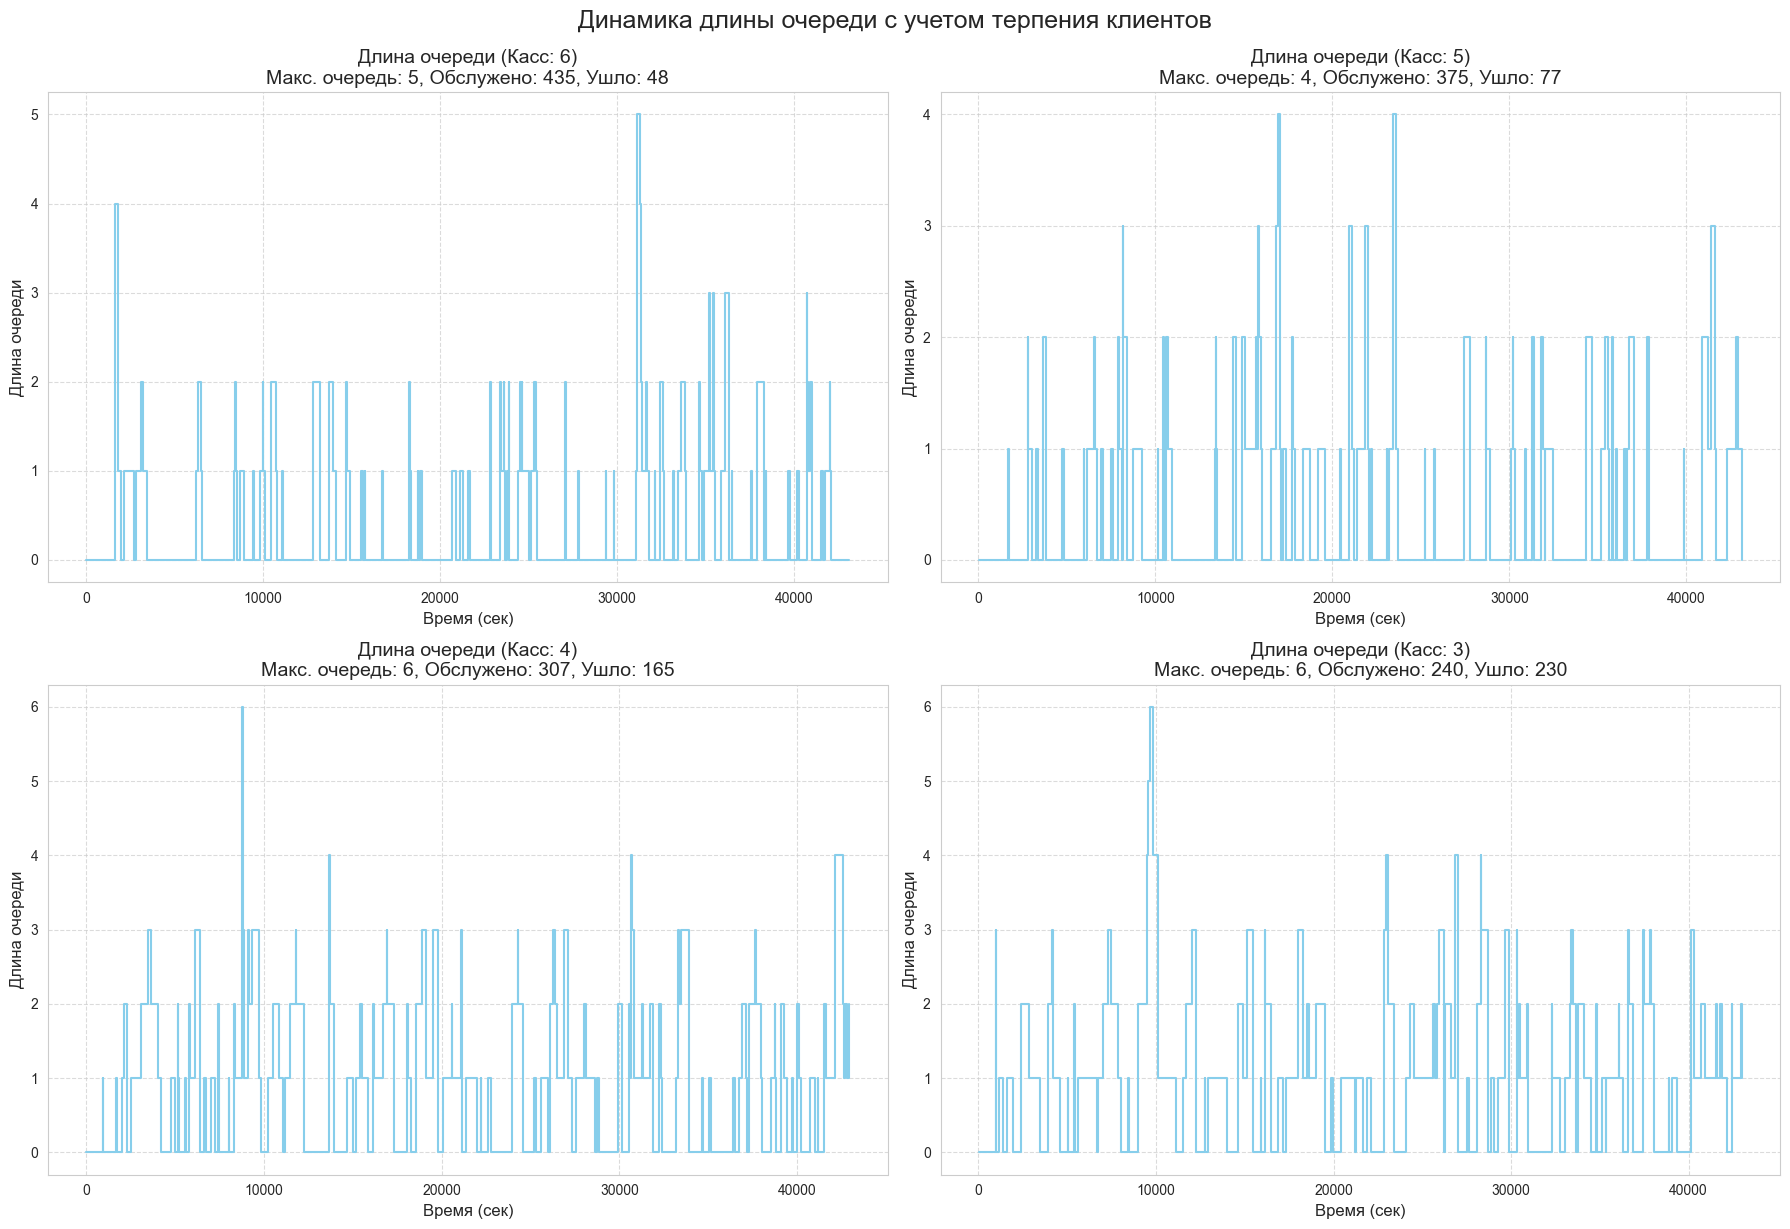

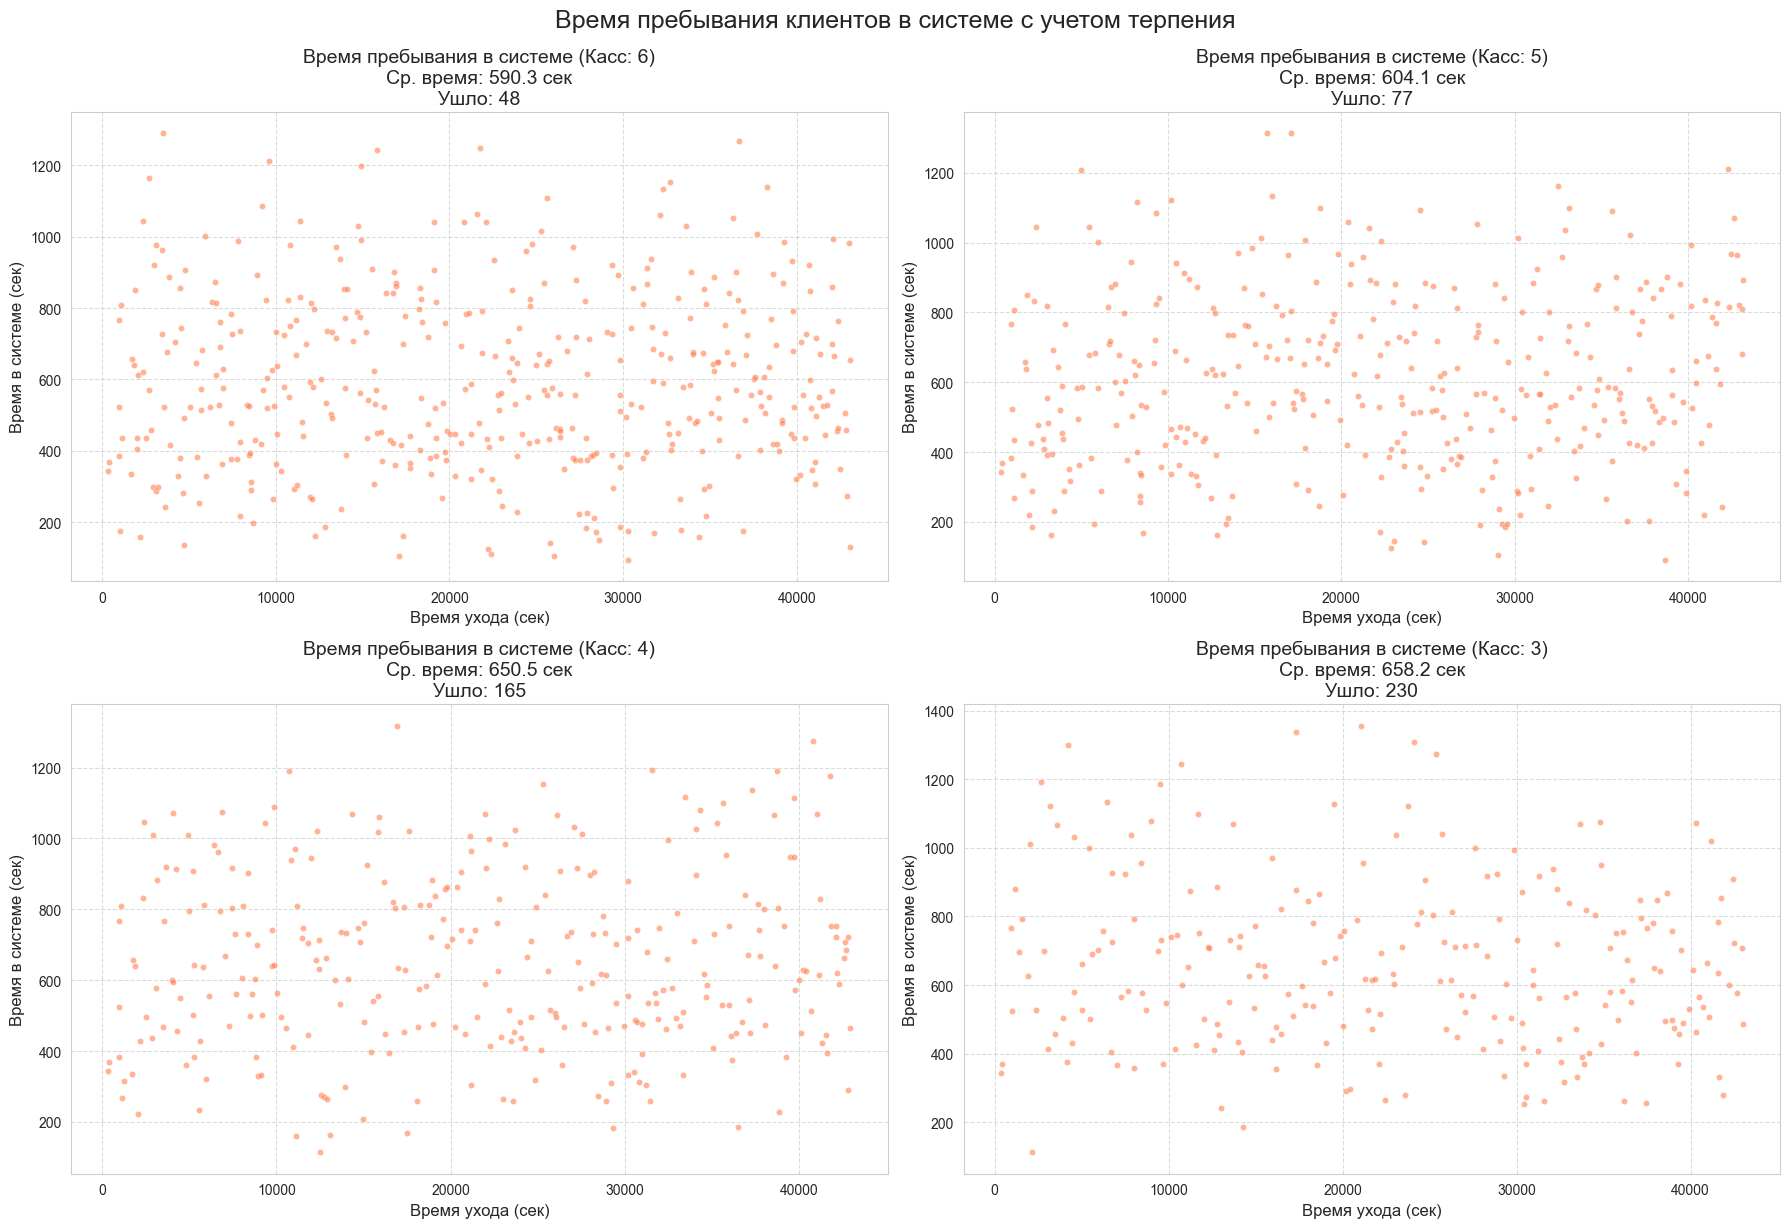

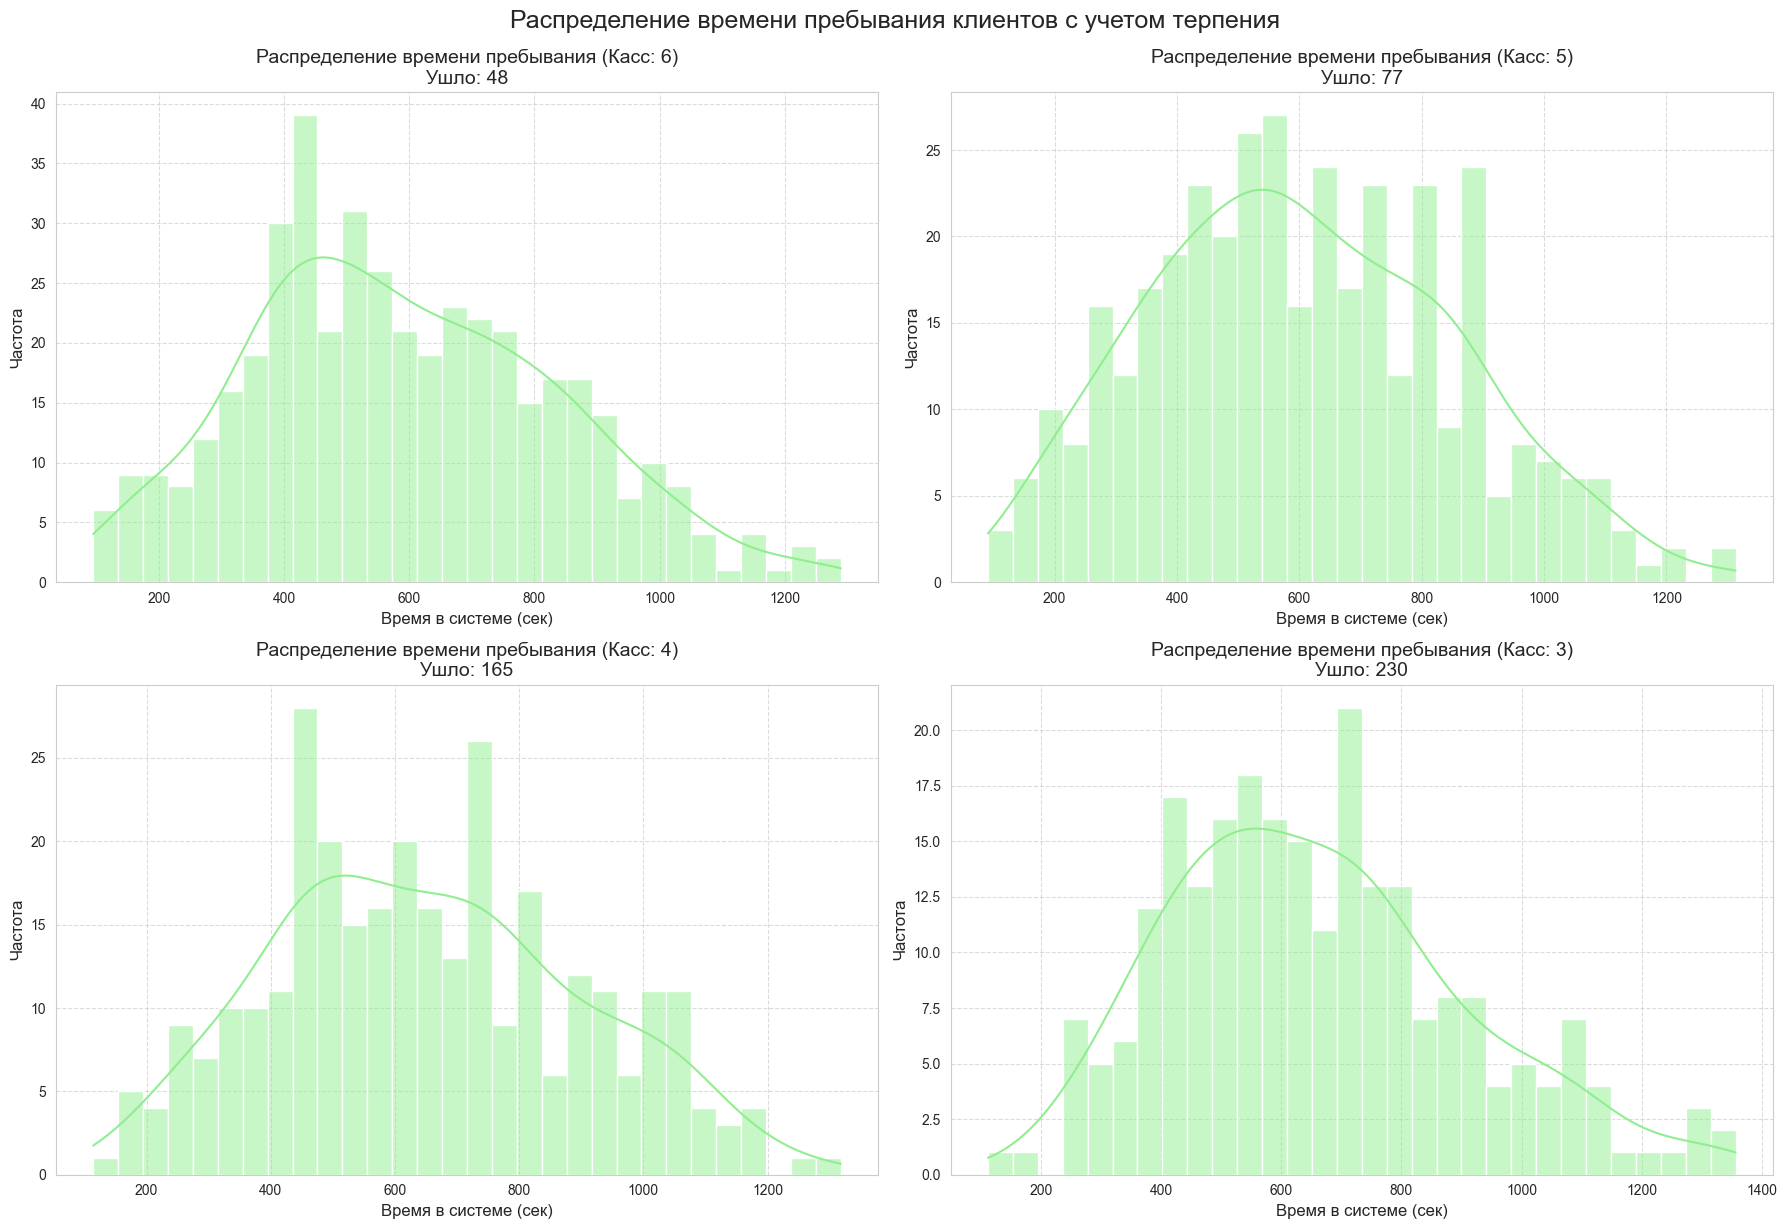

In [9]:
plt.figure(figsize=(18, 12))

for i, (config_name, (quelog, tservlog, lost_clients)) in enumerate(results_patience.items(), 1):
    num_cashiers = int(config_name.split('_')[1])

    # График длины очереди
    plt.subplot(2, 2, i)
    if quelog:
        times, lengths = zip(*quelog)
        plt.step(times, lengths, where='post', color='skyblue')
        max_queue = max(lengths) if lengths else 0
        total_served_clients = len(tservlog)
        plt.title(f'Длина очереди (Касс: {num_cashiers})\nМакс. очередь: {max_queue}, Обслужено: {total_served_clients}, Ушло: {lost_clients}', fontsize=14)
        plt.xlabel('Время (сек)', fontsize=12)
        plt.ylabel('Длина очереди', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f'Длина очереди (Касс: {num_cashiers})\nОчереди не было\nУшло: {lost_clients}', fontsize=14)
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.suptitle('Динамика длины очереди с учетом терпения клиентов', y=1.02, fontsize=18)
plt.show()

plt.figure(figsize=(18, 12))
for i, (config_name, (quelog, tservlog, lost_clients)) in enumerate(results_patience.items(), 1):
    num_cashiers = int(config_name.split('_')[1])

    # График времени пребывания
    plt.subplot(2, 2, i)
    if tservlog:
        times, durations = zip(*tservlog)
        sns.scatterplot(x=list(times), y=list(durations), s=20, alpha=0.6, color='coral')
        avg_time = sum(durations)/len(durations) if durations else 0
        plt.title(f'Время пребывания в системе (Касс: {num_cashiers})\nСр. время: {avg_time:.1f} сек\nУшло: {lost_clients}', fontsize=14)
        plt.xlabel('Время ухода (сек)', fontsize=12)
        plt.ylabel('Время в системе (сек)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f'Время пребывания в системе (Касс: {num_cashiers})\nНет данных\nУшло: {lost_clients}', fontsize=14)
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(5))

plt.tight_layout()
plt.suptitle('Время пребывания клиентов в системе с учетом терпения', y=1.02, fontsize=18)
plt.show()

# Дополнительные графики: гистограммы времени пребывания
plt.figure(figsize=(18, 12))
for i, (config_name, (quelog, tservlog, lost_clients)) in enumerate(results_patience.items(), 1):
    num_cashiers = int(config_name.split('_')[1])

    plt.subplot(2, 2, i)
    if tservlog:
        durations = [d for _, d in tservlog]
        sns.histplot(durations, bins=30, kde=True, color='lightgreen')
        plt.title(f'Распределение времени пребывания (Касс: {num_cashiers})\nУшло: {lost_clients}', fontsize=14)
        plt.xlabel('Время в системе (сек)', fontsize=12)
        plt.ylabel('Частота', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title(f'Распределение времени пребывания (Касс: {num_cashiers})\nНет данных\nУшло: {lost_clients}', fontsize=14)

plt.tight_layout()
plt.suptitle('Распределение времени пребывания клиентов с учетом терпения', y=1.02, fontsize=18)
plt.show()

## Сравнение моделей: с терпением и без

Сравним ключевые метрики двух моделей, чтобы наглядно продемонстрировать влияние терпения клиентов на производительность системы.

   Кассы       Модель  Макс. очередь  Обслужено клиентов  Среднее время в системе (сек)  Потеряно клиентов
0      6      Базовая             10                 465                     870.234409                  0
1      6  С терпением              5                 435                     590.255172                 48
2      5      Базовая             69                 394                    3351.304569                  0
3      5  С терпением              4                 375                     604.149333                 77
4      4      Базовая            164                 311                    7566.479100                  0
5      4  С терпением              6                 307                     650.521173                165
6      3      Базовая            235                 232                   11579.642241                  0
7      3  С терпением              6                 240                     658.170833                230


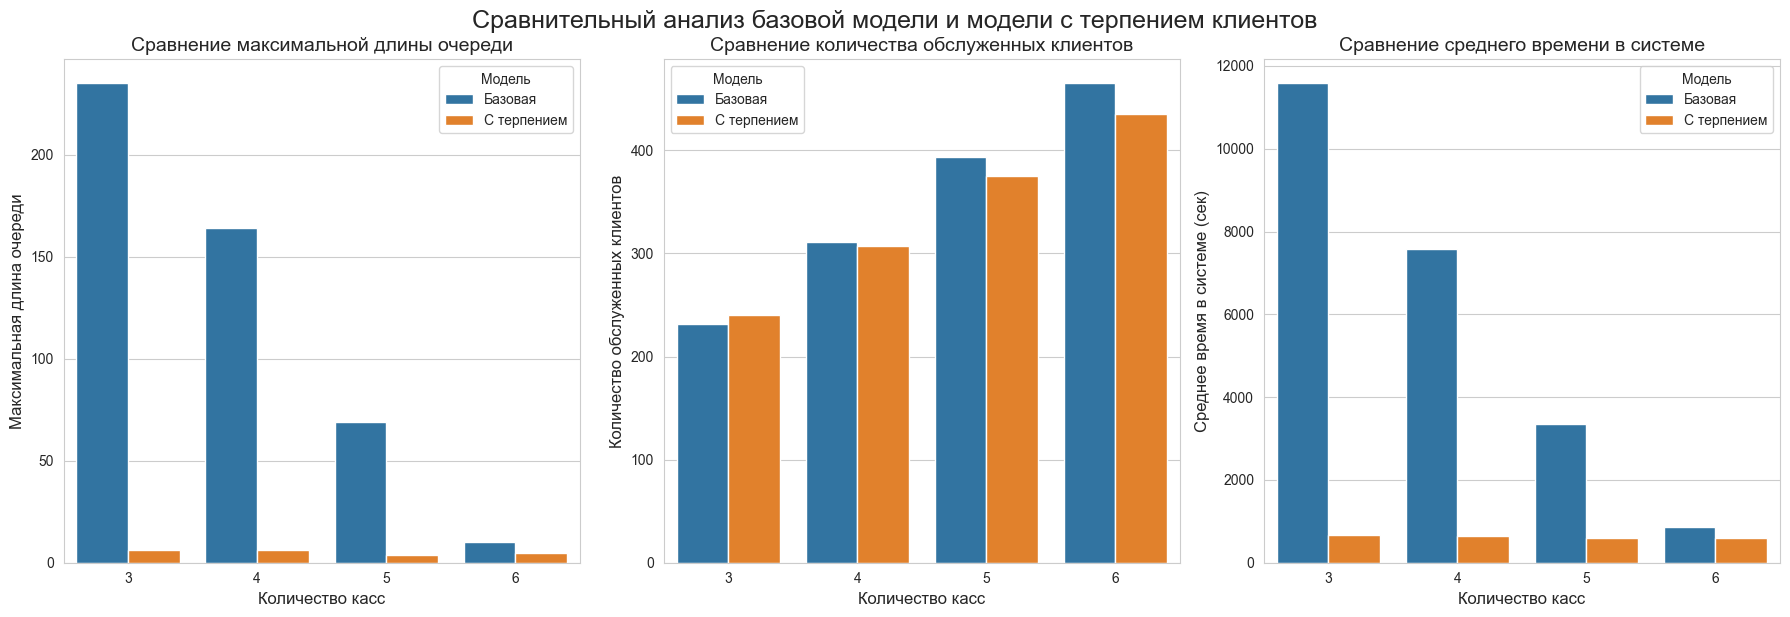

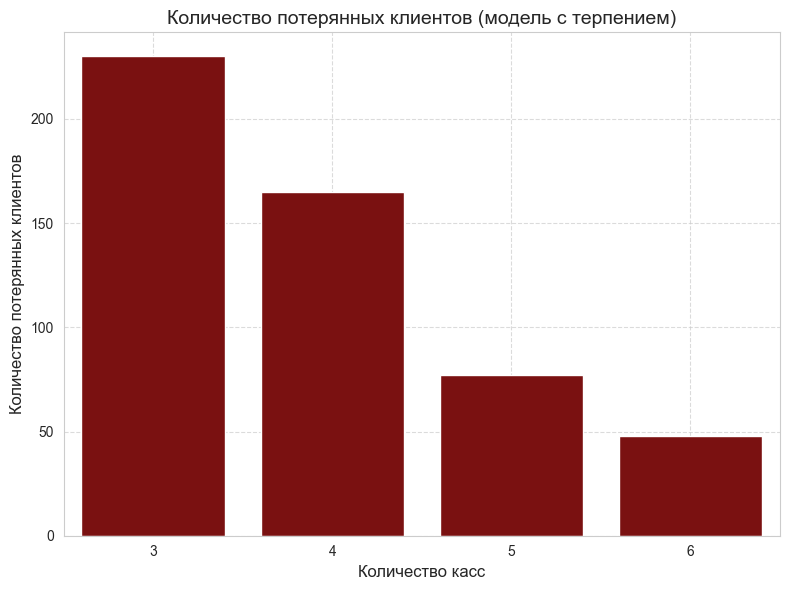

In [10]:
comparison_data = []

for cap in configs_base:
    # Базовая модель
    quelog_base, tservlog_base = results_base[f'config_{cap}_cashiers']
    max_queue_base = max([l for _, l in quelog_base]) if quelog_base else 0
    total_served_base = len(tservlog_base)
    avg_time_base = sum([d for _, d in tservlog_base])/len(tservlog_base) if tservlog_base else 0

    # Модель с терпением
    quelog_patience, tservlog_patience, lost_clients_patience = results_patience[f'config_{cap}_cashiers']
    max_queue_patience = max([l for _, l in quelog_patience]) if quelog_patience else 0
    total_served_patience = len(tservlog_patience)
    avg_time_patience = sum([d for _, d in tservlog_patience])/len(tservlog_patience) if tservlog_patience else 0

    comparison_data.append({
        'Кассы': cap,
        'Модель': 'Базовая',
        'Макс. очередь': max_queue_base,
        'Обслужено клиентов': total_served_base,
        'Среднее время в системе (сек)': avg_time_base,
        'Потеряно клиентов': 0
    })
    comparison_data.append({
        'Кассы': cap,
        'Модель': 'С терпением',
        'Макс. очередь': max_queue_patience,
        'Обслужено клиентов': total_served_patience,
        'Среднее время в системе (сек)': avg_time_patience,
        'Потеряно клиентов': lost_clients_patience
    })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string())

# Визуализация сравнения
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='Кассы', y='Макс. очередь', hue='Модель', data=df_comparison)
plt.title('Сравнение максимальной длины очереди', fontsize=14)
plt.ylabel('Максимальная длина очереди', fontsize=12)
plt.xlabel('Количество касс', fontsize=12)

plt.subplot(1, 3, 2)
sns.barplot(x='Кассы', y='Обслужено клиентов', hue='Модель', data=df_comparison)
plt.title('Сравнение количества обслуженных клиентов', fontsize=14)
plt.ylabel('Количество обслуженных клиентов', fontsize=12)
plt.xlabel('Количество касс', fontsize=12)

plt.subplot(1, 3, 3)
sns.barplot(x='Кассы', y='Среднее время в системе (сек)', hue='Модель', data=df_comparison)
plt.title('Сравнение среднего времени в системе', fontsize=14)
plt.ylabel('Среднее время в системе (сек)', fontsize=12)
plt.xlabel('Количество касс', fontsize=12)

plt.tight_layout()
plt.suptitle('Сравнительный анализ базовой модели и модели с терпением клиентов', y=1.02, fontsize=18)
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='Кассы', y='Потеряно клиентов', data=df_comparison[df_comparison['Модель'] == 'С терпением'], color='darkred')
plt.title('Количество потерянных клиентов (модель с терпением)', fontsize=14)
plt.ylabel('Количество потерянных клиентов', fontsize=12)
plt.xlabel('Количество касс', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Выводы

На основе проведенных симуляций можно сделать следующие выводы:

- **Влияние терпения на длину очереди:** При учете терпения клиентов максимальная длина очереди значительно сокращается. Это связано с тем, что "нетерпеливые" клиенты покидают систему, не дожидаясь обслуживания, что уменьшает нагрузку на очередь.

- **Обслуженные и потерянные клиенты:** Общее количество обслуженных клиентов в модели с терпением, как правило, меньше, чем в базовой модели, из-за ушедших клиентов. Количество потерянных клиентов является важной метрикой для оценки качества обслуживания и потенциальных потерь для бизнеса.

- **Среднее время пребывания в системе:** Среднее время пребывания в системе для обслуженных клиентов сокращается в модели с терпением. Это логично, так как клиенты, которые остаются в очереди, имеют более короткое время ожидания, а те, кто столкнулся бы с долгим ожиданием, просто уходят.

- **Доля "быстрых" обслуживаний:** С учетом терпения, доля обслуживаний, которые занимают относительно короткое время (например, ≤5 минут), увеличивается, поскольку клиенты, которые предвидели бы длительное ожидание, не остаются в системе.

- **Оптимизация количества касс:** Результаты симуляции показывают, что существует оптимальное количество касс для минимизации очереди и ожидания, балансируя при этом потери клиентов. Например, снижение числа касс с 6 до 5 или 4 может привести к управляемому увеличению очереди, но дальнейшее снижение до 3 касс приводит к резкому росту очереди и значительному числу потерянных клиентов.

Эти выводы подчеркивают важность учета поведенческих факторов клиентов (таких как терпение) при моделировании систем обслуживания для получения более реалистичных и полезных для принятия решений результатов.